# Notebook 02 — Metadata Completeness & Missing-Value Analysis

## Objective

Measure **field completeness** across OpenAlex, Crossref, and Local repositories, then break
missingness down by **publication type** and **institution / repository**.

Results drive enrichment rules in Notebook 03:

- Which fields are strong / weak in each source?
- Which types (thesis, conference, journal) are most incomplete?
- Which institutes / repos have the biggest metadata gaps?
- Given OpenAlex as source of truth, which missing fields should Crossref / Local fill?

## Columns used (from the live datasets)

| Source | Key columns |
|--------|-------------|
| OpenAlex | `doi`, `title`, `type`, `publication_year`, `authors`, `sri_lankan_institutions`, `source_name`, `cited_by_count`, `topics`, `issn_l`, `volume`, `issue`, `license`, … |
| Crossref | `DOI`, `title`, `abstract`, `type`, `author_name`, `author_affiliation`, `author_ORCID`, `container-title`, `ISSN`, `funder_name`, `license_URL`, `event.*`, `references_json`, … |
| Local | `doi`, `title`, `publication_type`, `source_institution_id`, `authors`, `abstract`, `keywords`, `journal`, `publisher`, `url`, `rights`, … |

**Outputs:** `./outputs/notebook02/*.csv`


## 1. Imports & setup


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("./outputs/notebook02")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output:", OUTPUT_DIR.resolve())


Output: /home/asma/Projects/researchlanka-ai/notebooks/outputs/notebook02


## 2. Load datasets


In [2]:
def load_dataset(path):
    return pd.read_csv(path, low_memory=False)


openalex_df = load_dataset(DATA_DIR / "raw/open-alex/open_alex.csv")
crossref_df = load_dataset(DATA_DIR / "processed/crossref_clean_2016_2026_enriched.csv")
local_df = load_dataset(DATA_DIR / "raw/open-alex/repositories_combined.csv")

local_df["publication_year"] = pd.to_numeric(local_df["publication_year"], errors="coerce")
local_df = local_df[local_df["publication_year"] >= 2016].copy()

datasets = {"OpenAlex": openalex_df, "Crossref": crossref_df, "Local": local_df}
for name, df in datasets.items():
    print(f"{name:10s} {df.shape}")


OpenAlex   (73289, 34)
Crossref   (65946, 55)
Local      (60812, 19)


## 3. Missing-value helpers


In [3]:
MISSING_TOKENS = {"", " ", "nan", "none", "null", "[]", "{}", "n/a", "na"}


def is_present(series: pd.Series) -> pd.Series:
    mask = series.notna()
    as_str = series.astype(str).str.strip().str.lower()
    return mask & ~as_str.isin(MISSING_TOKENS)


def quality_label(score: float) -> str:
    if score >= 95:
        return "Excellent"
    if score >= 70:
        return "Good"
    if score >= 30:
        return "Weak"
    return "Poor"


## 4. Canonical field mapping (correct column names)

Each canonical field lists candidate columns in that source.
A record is complete for a field if **any** mapped column is present.


In [4]:
FIELD_MAP = {
    "OpenAlex": {
        "publication_id": ["openalex_id"],
        "doi": ["doi"],
        "title": ["title"],
        "publication_year": ["publication_year"],
        "publication_date": ["publication_date"],
        "publication_type": ["type"],
        "authors": ["authors"],
        "sri_lankan_authors": ["sri_lankan_authors"],
        "author_affiliation": ["institutions", "sri_lankan_institutions"],
        "institution": ["sri_lankan_institutions"],
        "publisher": ["publisher"],
        "journal": ["source_name"],
        "issn": ["issn_l"],
        "volume": ["volume"],
        "issue": ["issue"],
        "page": ["first_page", "last_page"],
        "citation_count": ["cited_by_count"],
        "reference_count": ["referenced_works_count"],
        "topics": ["topics", "concepts"],
        "research_field": ["primary_field", "primary_subfield", "primary_domain"],
        "primary_topic": ["primary_topic"],
        "language": ["language"],
        "url": ["landing_page_url"],
        "pdf_url": ["pdf_url"],
        "open_access_status": ["is_oa", "oa_status"],
        "license": ["license"],
        "abstract": [],
        "author_orcid": [],
        "keywords": [],
        "funding": [],
        "references": [],
        "event": [],
    },
    "Crossref": {
        "publication_id": ["DOI"],
        "doi": ["DOI"],
        "title": ["title"],
        "abstract": ["abstract"],
        "publication_year": ["publication_year"],
        "publication_date": ["issued.date-parts", "published.date-parts"],
        "publication_type": ["type"],
        "authors": ["author_name", "author_given", "author_family"],
        "author_affiliation": ["author_affiliation"],
        "author_orcid": ["author_ORCID"],
        "publisher": ["publisher"],
        "journal": ["container-title"],
        "issn": ["ISSN"],
        "volume": ["volume"],
        "issue": ["issue"],
        "page": ["page", "article-number"],
        "citation_count": ["is-referenced-by-count"],
        "reference_count": ["reference-count"],
        "references": ["references_json"],
        "language": ["language"],
        "url": ["URL"],
        "license": ["license_URL"],
        "funding": ["funder_name", "funder_DOI", "funder_id", "funder_award"],
        "event": ["event.name", "event.location", "event.acronym", "event.sponsor"],
        "institution": ["author_affiliation"],
        "topics": [],
        "research_field": [],
        "primary_topic": [],
        "keywords": [],
        "pdf_url": [],
        "open_access_status": [],
        "sri_lankan_authors": [],
    },
    "Local": {
        "publication_id": ["source_record_id"],
        "doi": ["doi"],
        "title": ["title"],
        "abstract": ["abstract"],
        "publication_year": ["publication_year"],
        "publication_date": ["publication_date"],
        "publication_type": ["publication_type"],
        "authors": ["authors"],
        "publisher": ["publisher"],
        "journal": ["journal"],
        "keywords": ["keywords"],
        "language": ["language"],
        "url": ["url"],
        "license": ["rights"],
        "institution": ["source_institution_id"],
        "author_affiliation": ["source_institution_id"],
        "citation_count": [],
        "reference_count": [],
        "references": [],
        "topics": [],
        "research_field": [],
        "primary_topic": [],
        "issn": [],
        "volume": [],
        "issue": [],
        "page": [],
        "author_orcid": [],
        "funding": [],
        "event": [],
        "pdf_url": [],
        "open_access_status": [],
        "sri_lankan_authors": [],
    },
}

TYPE_MAP = {
    "article": "journal_article",
    "journal-article": "journal_article",
    "journal article": "journal_article",
    "conference-paper": "conference_paper",
    "proceedings-article": "conference_paper",
    "conference-full-text": "conference_paper",
    "conference-abstract": "conference_abstract",
    "conference-extended-abstract": "conference_abstract",
    "book-chapter": "book_chapter",
    "book": "book",
    "monograph": "book",
    "edited-book": "book",
    "preprint": "preprint",
    "posted-content": "preprint",
    "review": "review",
    "dataset": "dataset",
    "thesis": "thesis",
    "dissertation": "thesis",
    "thesis-full-text": "thesis",
    "thesis-abstract": "thesis",
    "report": "report",
    "other": "other",
}


def canonical_type(x):
    if pd.isna(x):
        return "unknown"
    key = str(x).lower().strip().replace("_", "-")
    key = re.sub(r"\s+", " ", key)
    return TYPE_MAP.get(key) or TYPE_MAP.get(key.replace(" ", "-")) or "other"


## 5. Overall canonical completeness


In [5]:
def canonical_completeness(df, dataset_name, mapping):
    total = len(df)
    rows = []
    field_map = mapping[dataset_name]
    for field, cols in field_map.items():
        available_cols = [c for c in cols if c in df.columns]
        if not available_cols:
            available = 0
            missing = total
            completeness = 0.0
        else:
            present = pd.DataFrame({c: is_present(df[c]) for c in available_cols}).any(axis=1)
            available = int(present.sum())
            missing = total - available
            completeness = round(100 * available / total, 2) if total else 0.0
        rows.append({
            "dataset": dataset_name,
            "canonical_field": field,
            "mapped_source_columns": ",".join(available_cols) if available_cols else "",
            "total_records": total,
            "present_records": available,
            "missing_records": missing,
            "completeness_percentage": completeness,
            "quality_category": quality_label(completeness),
        })
    return pd.DataFrame(rows)


canonical_quality = pd.concat(
    [canonical_completeness(df, name, FIELD_MAP) for name, df in datasets.items()],
    ignore_index=True,
)
canonical_quality.to_csv(OUTPUT_DIR / "metadata_completeness_canonical.csv", index=False)
canonical_quality.head(20)


,dataset,canonical_field,mapped_source_columns,total_records,present_records,missing_records,completeness_percentage,quality_category
0,OpenAlex,publication_id,openalex_id,73289,73289,0,100.00,Excellent
1,OpenAlex,doi,doi,73289,71400,1889,97.42,Excellent
2,OpenAlex,title,title,73289,73204,85,99.88,Excellent
3,OpenAlex,publication_year,publication_year,73289,73289,0,100.00,Excellent
4,OpenAlex,publication_date,publication_date,73289,73289,0,100.00,Excellent
5,OpenAlex,publication_type,type,73289,73289,0,100.00,Excellent
6,OpenAlex,authors,authors,73289,73288,1,100.00,Excellent
7,OpenAlex,sri_lankan_authors,sri_lankan_authors,73289,73288,1,100.00,Excellent
8,OpenAlex,author_affiliation,"institutions,sri_lankan_institutions",73289,73289,0,100.00,Excellent
9,OpenAlex,institution,sri_lankan_institutions,73289,73289,0,100.00,Excellent


## 6. Completeness matrix (field × source)


In [6]:
field_matrix = canonical_quality.pivot(
    index="canonical_field", columns="dataset", values="completeness_percentage"
).fillna(0)
field_matrix = field_matrix.reindex(columns=["OpenAlex", "Crossref", "Local"])
field_matrix.to_csv(OUTPUT_DIR / "field_completeness_matrix.csv")
field_matrix.sort_values("OpenAlex", ascending=False)


dataset,OpenAlex,Crossref,Local
canonical_field,,,
author_affiliation,100.00,31.80,100.00
authors,100.00,99.22,98.21
citation_count,100.00,100.00,0.00
institution,100.00,31.80,100.00
open_access_status,100.00,0.00,0.00
publication_type,100.00,100.00,99.19
publication_year,100.00,99.75,100.00
publication_date,100.00,100.00,100.00
publication_id,100.00,100.00,100.00


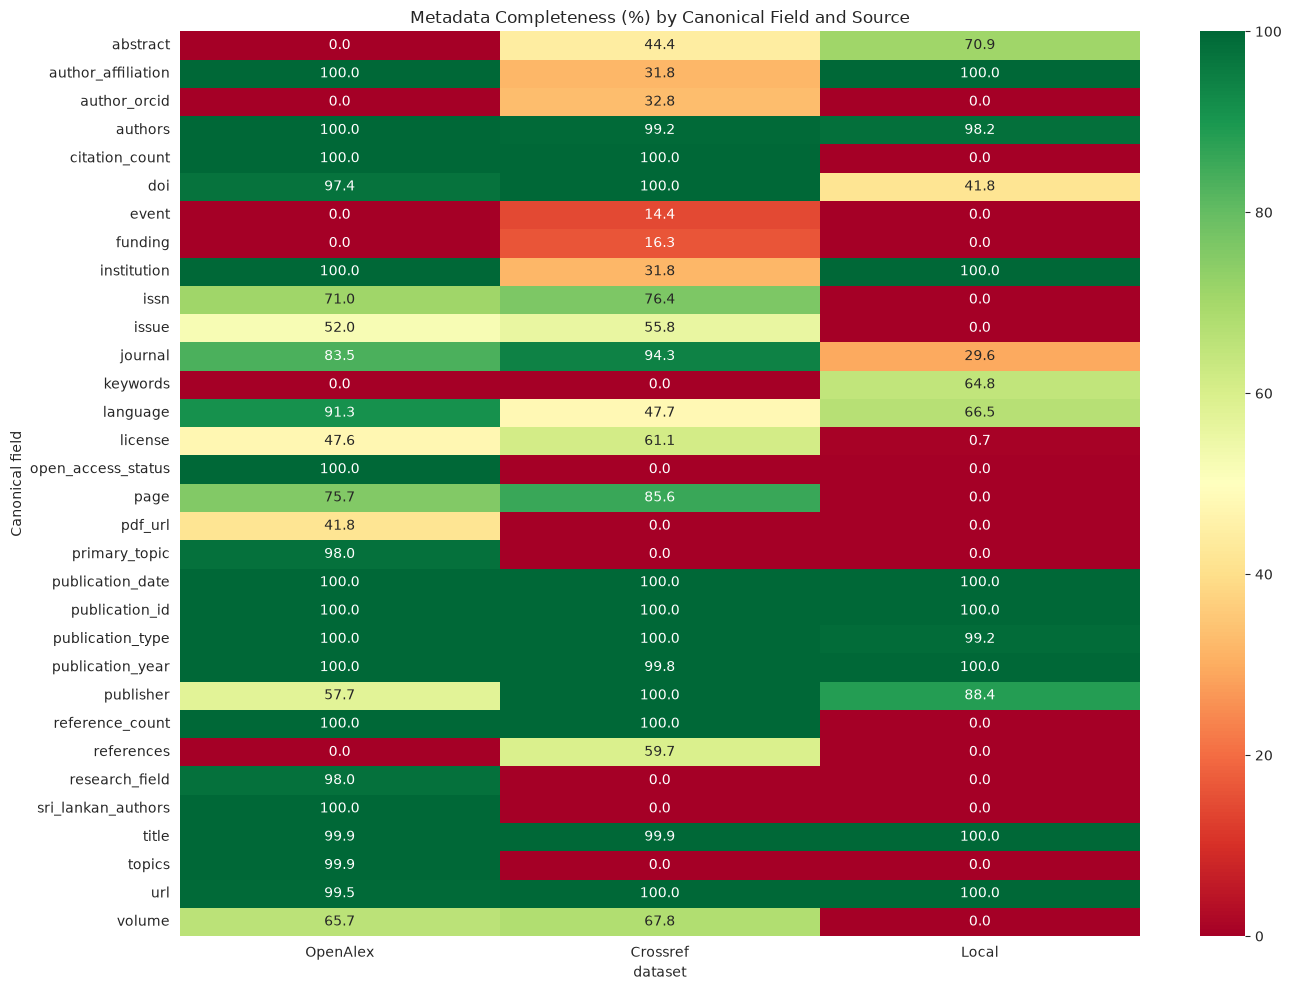

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(field_matrix, annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=100)
plt.title("Metadata Completeness (%) by Canonical Field and Source")
plt.ylabel("Canonical field")
plt.tight_layout()
plt.show()


## 7. Critical fields focus

Fields that matter most for search, dedup, enrichment, and analytics.


In [8]:
IMPORTANT_FIELDS = [
    "doi", "title", "abstract", "publication_year", "publication_type",
    "authors", "author_affiliation", "author_orcid", "institution",
    "publisher", "journal", "issn", "volume", "issue", "page",
    "citation_count", "reference_count", "references",
    "topics", "research_field", "keywords",
    "open_access_status", "license", "funding", "event", "url", "pdf_url",
]

critical_report = canonical_quality[
    canonical_quality["canonical_field"].isin(IMPORTANT_FIELDS)
].copy()
critical_report.to_csv(OUTPUT_DIR / "critical_metadata_fields.csv", index=False)
critical_report.sort_values(["canonical_field", "dataset"])


,dataset,canonical_field,mapped_source_columns,total_records,present_records,missing_records,completeness_percentage,quality_category
35,Crossref,abstract,abstract,65946,29275,36671,44.39,Weak
67,Local,abstract,abstract,60812,43123,17689,70.91,Good
26,OpenAlex,abstract,,73289,0,73289,0.00,Poor
40,Crossref,author_affiliation,author_affiliation,65946,20970,44976,31.80,Weak
79,Local,author_affiliation,source_institution_id,60812,60812,0,100.00,Excellent
...,...,...,...,...,...,...,...,...
76,Local,url,url,60812,60811,1,100.00,Excellent
22,OpenAlex,url,landing_page_url,73289,72952,337,99.54,Excellent
45,Crossref,volume,volume,65946,44721,21225,67.81,Weak
87,Local,volume,,60812,0,60812,0.00,Poor


## 8. Enrichment recommendation (OpenAlex = source of truth)

Highest completeness alone is not enough: OpenAlex remains the primary record.
Crossref / Local are recommended only for fields they uniquely or substantially improve.


In [9]:
PRIMARY_POLICY = {
    "doi": "OpenAlex",
    "title": "OpenAlex",
    "publication_year": "OpenAlex",
    "publication_date": "OpenAlex",
    "publication_type": "OpenAlex",
    "authors": "OpenAlex",
    "publisher": "OpenAlex",
    "journal": "OpenAlex",
    "citation_count": "OpenAlex",
    "topics": "OpenAlex",
    "research_field": "OpenAlex",
    "primary_topic": "OpenAlex",
    "open_access_status": "OpenAlex",
    "institution": "OpenAlex",
    "sri_lankan_authors": "OpenAlex",
    "pdf_url": "OpenAlex",
    "language": "OpenAlex",
    "abstract": "Crossref",
    "author_orcid": "Crossref",
    "issn": "Crossref",
    "volume": "Crossref",
    "issue": "Crossref",
    "page": "Crossref",
    "funding": "Crossref",
    "license": "Crossref",
    "references": "Crossref",
    "reference_count": "Crossref",
    "event": "Crossref",
    "keywords": "Local",
}

rows = []
for field in field_matrix.index:
    scores = field_matrix.loc[field].to_dict()
    best_by_completeness = max(scores, key=scores.get)
    preferred = PRIMARY_POLICY.get(field, best_by_completeness)

    oa = scores.get("OpenAlex", 0)
    cr = scores.get("Crossref", 0)
    loc = scores.get("Local", 0)

    if preferred == "OpenAlex" and oa >= 70:
        action = "keep_openalex"
    elif preferred == "Crossref" and cr > oa:
        action = "enrich_from_crossref_when_oa_missing"
    elif preferred == "Local" and loc > oa:
        action = "enrich_from_local_when_oa_missing"
    elif cr - oa >= 10:
        action = "consider_crossref_fill"
    elif loc - oa >= 10:
        action = "consider_local_fill"
    else:
        action = "keep_best_available"

    rows.append({
        "canonical_field": field,
        "openalex_pct": scores.get("OpenAlex", 0),
        "crossref_pct": scores.get("Crossref", 0),
        "local_pct": scores.get("Local", 0),
        "best_by_completeness": best_by_completeness,
        "preferred_primary_source": preferred,
        "enrichment_action": action,
        "gap_crossref_minus_oa": round(cr - oa, 2),
        "gap_local_minus_oa": round(loc - oa, 2),
    })

recommendation = pd.DataFrame(rows).sort_values("canonical_field")
recommendation.to_csv(OUTPUT_DIR / "recommended_field_sources.csv", index=False)
recommendation


,canonical_field,openalex_pct,crossref_pct,local_pct,best_by_completeness,preferred_primary_source,enrichment_action,gap_crossref_minus_oa,gap_local_minus_oa
0,abstract,0.00,44.39,70.91,Local,Crossref,enrich_from_crossref_when_oa_missing,44.39,70.91
1,author_affiliation,100.00,31.80,100.00,OpenAlex,OpenAlex,keep_openalex,-68.20,0.00
2,author_orcid,0.00,32.84,0.00,Crossref,Crossref,enrich_from_crossref_when_oa_missing,32.84,0.00
3,authors,100.00,99.22,98.21,OpenAlex,OpenAlex,keep_openalex,-0.78,-1.79
4,citation_count,100.00,100.00,0.00,OpenAlex,OpenAlex,keep_openalex,0.00,-100.00
5,doi,97.42,100.00,41.78,Crossref,OpenAlex,keep_openalex,2.58,-55.64
6,event,0.00,14.40,0.00,Crossref,Crossref,enrich_from_crossref_when_oa_missing,14.40,0.00
7,funding,0.00,16.28,0.00,Crossref,Crossref,enrich_from_crossref_when_oa_missing,16.28,0.00
8,institution,100.00,31.80,100.00,OpenAlex,OpenAlex,keep_openalex,-68.20,0.00
9,issn,71.05,76.44,0.00,Crossref,Crossref,enrich_from_crossref_when_oa_missing,5.39,-71.05


## 9. Source-level average completeness


In [10]:
source_score = (
    canonical_quality.groupby("dataset")["completeness_percentage"]
    .mean()
    .reset_index()
    .rename(columns={"completeness_percentage": "average_metadata_completeness"})
)
source_score.to_csv(OUTPUT_DIR / "source_average_completeness.csv", index=False)
source_score


,dataset,average_metadata_completeness
0,Crossref,56.838750
1,Local,39.377187
2,OpenAlex,71.222813


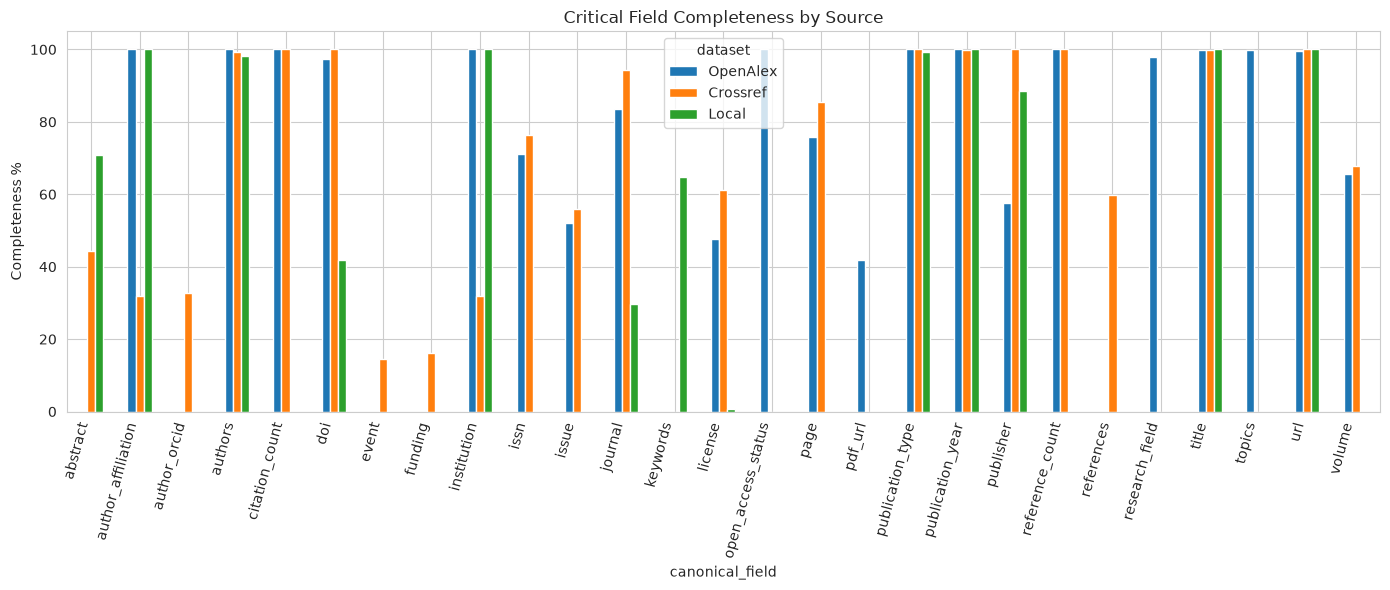

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
plot = critical_report.pivot(
    index="canonical_field", columns="dataset", values="completeness_percentage"
)
plot = plot.reindex(columns=["OpenAlex", "Crossref", "Local"])
plot.plot(kind="bar", ax=ax)
ax.set_ylabel("Completeness %")
ax.set_title("Critical Field Completeness by Source")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


## 10. Type-wise completeness (critical fields)

Answers: for journal articles vs conference papers vs theses, which metadata is missing?


In [12]:
TYPE_COL = {
    "OpenAlex": "type",
    "Crossref": "type",
    "Local": "publication_type",
}

CRITICAL_FOR_TYPE = [
    "doi", "title", "abstract", "authors", "publisher", "journal",
    "issn", "volume", "issue", "page", "citation_count", "reference_count",
    "license", "funding", "keywords", "topics",
]


def completeness_by_type(df, dataset_name, fields=CRITICAL_FOR_TYPE):
    type_col = TYPE_COL[dataset_name]
    if type_col not in df.columns:
        return pd.DataFrame()
    tmp = df.copy()
    tmp["_ctype"] = tmp[type_col].map(canonical_type)
    field_map = FIELD_MAP[dataset_name]
    rows = []
    for ctype, group in tmp.groupby("_ctype"):
        total = len(group)
        if total < 20:
            continue
        for field in fields:
            cols = [c for c in field_map.get(field, []) if c in group.columns]
            if not cols:
                pct = 0.0
            else:
                present = pd.DataFrame({c: is_present(group[c]) for c in cols}).any(axis=1)
                pct = round(100 * present.mean(), 2)
            rows.append({
                "dataset": dataset_name,
                "canonical_type": ctype,
                "records": total,
                "canonical_field": field,
                "completeness_percentage": pct,
            })
    return pd.DataFrame(rows)


type_completeness = pd.concat(
    [completeness_by_type(df, name) for name, df in datasets.items()],
    ignore_index=True,
)
type_completeness.to_csv(OUTPUT_DIR / "completeness_by_publication_type.csv", index=False)
type_completeness.head(30)


,dataset,canonical_type,records,canonical_field,completeness_percentage
0,OpenAlex,book,178,doi,96.63
1,OpenAlex,book,178,title,100.00
2,OpenAlex,book,178,abstract,0.00
3,OpenAlex,book,178,authors,100.00
4,OpenAlex,book,178,publisher,41.57
5,OpenAlex,book,178,journal,60.67
6,OpenAlex,book,178,issn,21.35
7,OpenAlex,book,178,volume,0.00
8,OpenAlex,book,178,issue,0.00
9,OpenAlex,book,178,page,0.00


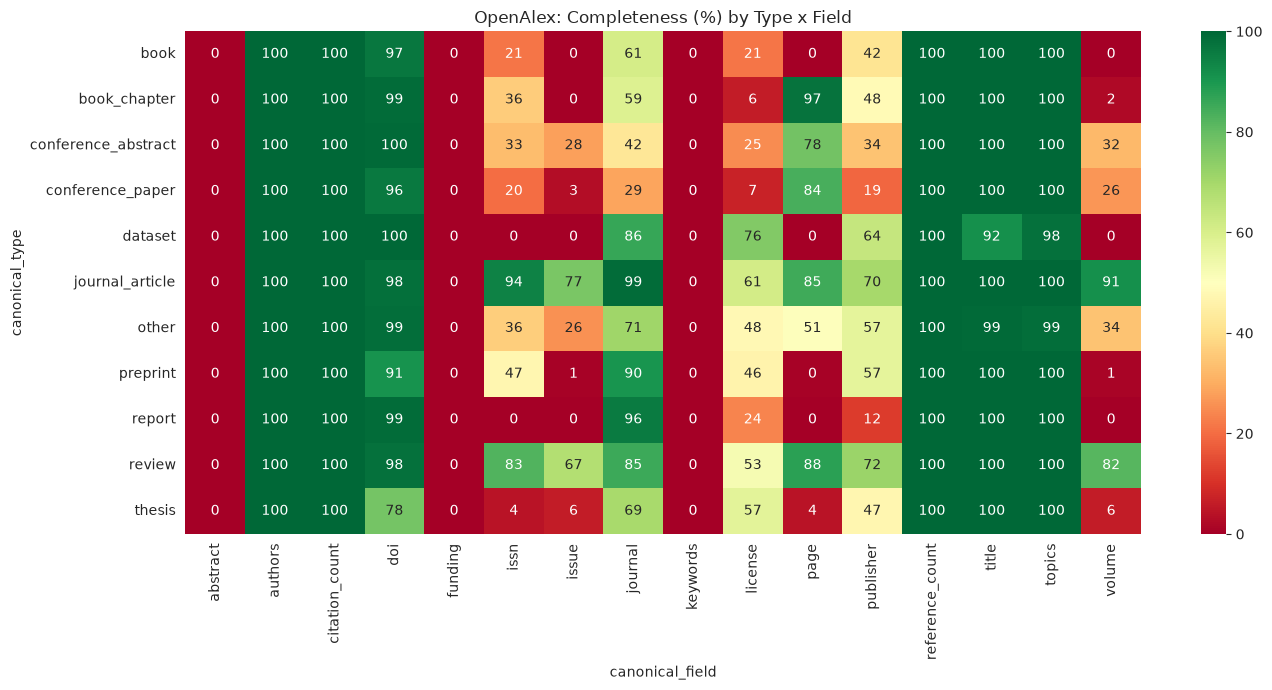

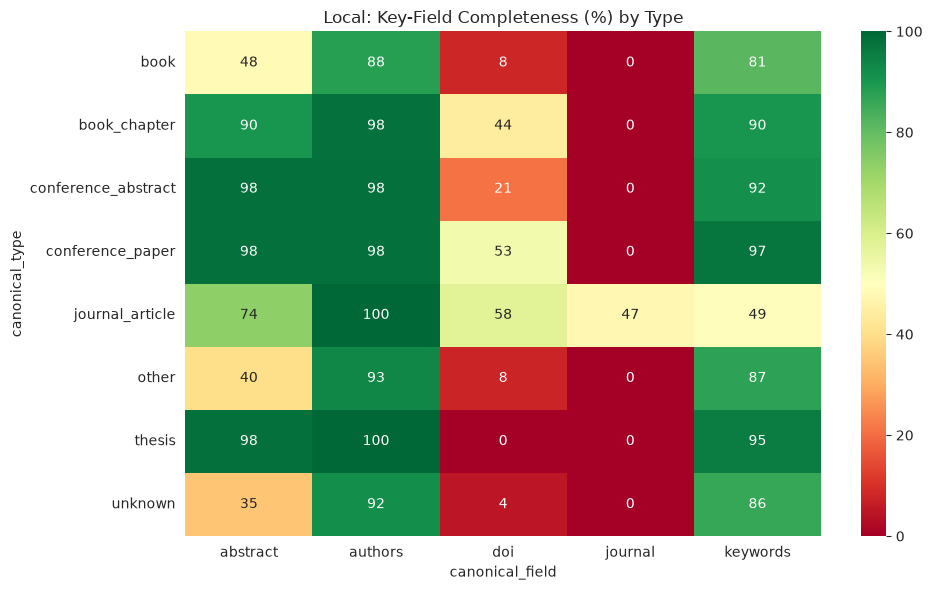

In [13]:
oa_type = type_completeness[type_completeness["dataset"] == "OpenAlex"]
if not oa_type.empty:
    mat = oa_type.pivot(
        index="canonical_type", columns="canonical_field", values="completeness_percentage"
    )
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.heatmap(mat, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100, ax=ax)
    ax.set_title("OpenAlex: Completeness (%) by Type x Field")
    plt.tight_layout()
    plt.show()

local_focus = type_completeness[
    (type_completeness["dataset"] == "Local")
    & (type_completeness["canonical_field"].isin(
        ["doi", "abstract", "authors", "keywords", "journal"]
    ))
]
if not local_focus.empty:
    mat = local_focus.pivot(
        index="canonical_type", columns="canonical_field", values="completeness_percentage"
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(mat, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100, ax=ax)
    ax.set_title("Local: Key-Field Completeness (%) by Type")
    plt.tight_layout()
    plt.show()


## 11. Institute-wise completeness

- OpenAlex: explode `sri_lankan_institutions`
- Local: group by `source_institution_id`


In [14]:
INST_FIELDS = [
    "doi", "title", "abstract", "authors", "publisher", "journal", "keywords", "license"
]


def completeness_by_institution_openalex(df, top_n=15):
    if "sri_lankan_institutions" not in df.columns:
        return pd.DataFrame()
    base = df.copy()
    exploded_idx = []
    inst_names = []
    for idx, val in base["sri_lankan_institutions"].astype(str).items():
        if val.lower() in {"nan", "none", "null", ""}:
            continue
        for part in re.split(r"[;|]", val):
            part = part.strip()
            if part:
                exploded_idx.append(idx)
                inst_names.append(part)
    if not exploded_idx:
        return pd.DataFrame()
    exp = base.loc[exploded_idx].copy()
    exp["institution"] = inst_names

    top = exp["institution"].value_counts().head(top_n).index
    exp = exp[exp["institution"].isin(top)]
    field_map = FIELD_MAP["OpenAlex"]
    rows = []
    for inst, group in exp.groupby("institution"):
        total = len(group)
        for field in INST_FIELDS:
            cols = [c for c in field_map.get(field, []) if c in group.columns]
            if not cols:
                pct = 0.0
            else:
                present = pd.DataFrame({c: is_present(group[c]) for c in cols}).any(axis=1)
                pct = round(100 * present.mean(), 2)
            rows.append({
                "dataset": "OpenAlex",
                "institution": inst,
                "records": total,
                "canonical_field": field,
                "completeness_percentage": pct,
            })
    return pd.DataFrame(rows)


def completeness_by_institution_local(df):
    if "source_institution_id" not in df.columns:
        return pd.DataFrame()
    field_map = FIELD_MAP["Local"]
    rows = []
    for inst, group in df.groupby("source_institution_id"):
        total = len(group)
        for field in INST_FIELDS:
            cols = [c for c in field_map.get(field, []) if c in group.columns]
            if not cols:
                pct = 0.0
            else:
                present = pd.DataFrame({c: is_present(group[c]) for c in cols}).any(axis=1)
                pct = round(100 * present.mean(), 2)
            rows.append({
                "dataset": "Local",
                "institution": inst,
                "records": total,
                "canonical_field": field,
                "completeness_percentage": pct,
            })
    return pd.DataFrame(rows)


inst_completeness = pd.concat([
    completeness_by_institution_openalex(openalex_df, top_n=12),
    completeness_by_institution_local(local_df),
], ignore_index=True)
inst_completeness.to_csv(OUTPUT_DIR / "completeness_by_institution.csv", index=False)
inst_completeness.head(25)


,dataset,institution,records,canonical_field,completeness_percentage
0,OpenAlex,Department of Archaeology,3734,doi,98.74
1,OpenAlex,Department of Archaeology,3734,title,100.00
2,OpenAlex,Department of Archaeology,3734,abstract,0.00
3,OpenAlex,Department of Archaeology,3734,authors,100.00
4,OpenAlex,Department of Archaeology,3734,publisher,45.18
5,OpenAlex,Department of Archaeology,3734,journal,94.99
6,OpenAlex,Department of Archaeology,3734,keywords,0.00
7,OpenAlex,Department of Archaeology,3734,license,40.09
8,OpenAlex,National Hospital of Sri Lanka,2312,doi,98.75
9,OpenAlex,National Hospital of Sri Lanka,2312,title,100.00


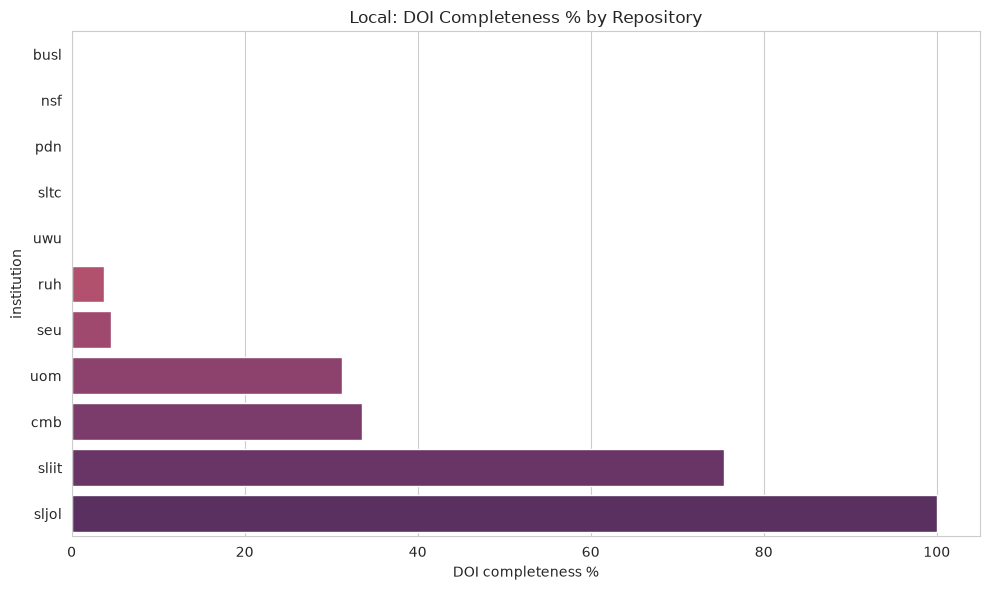

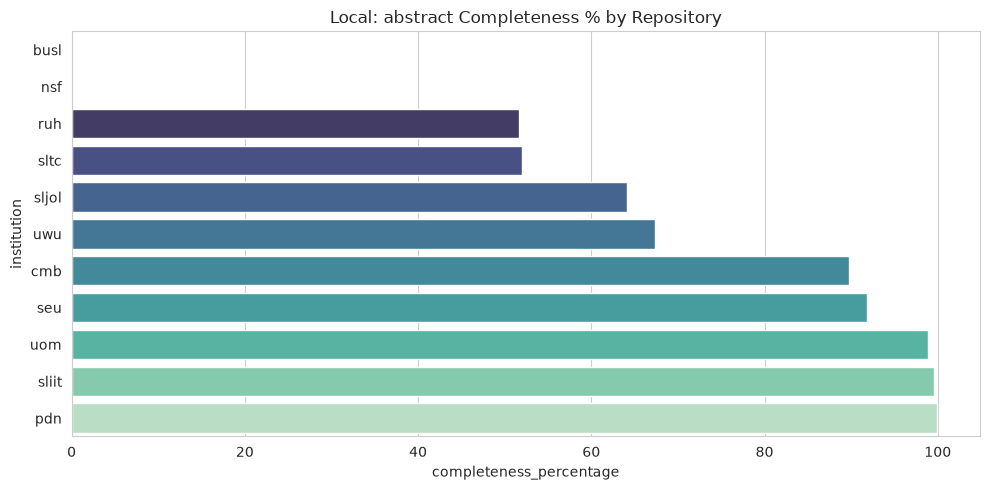

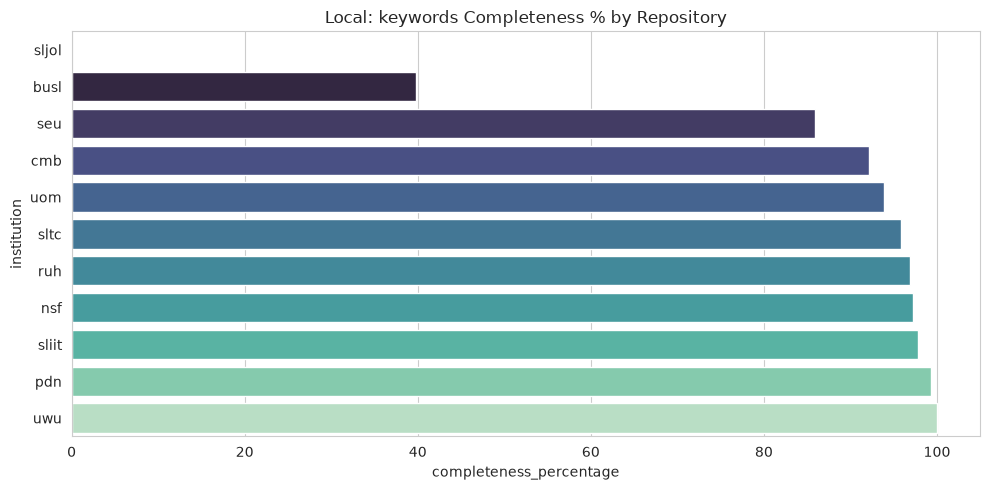

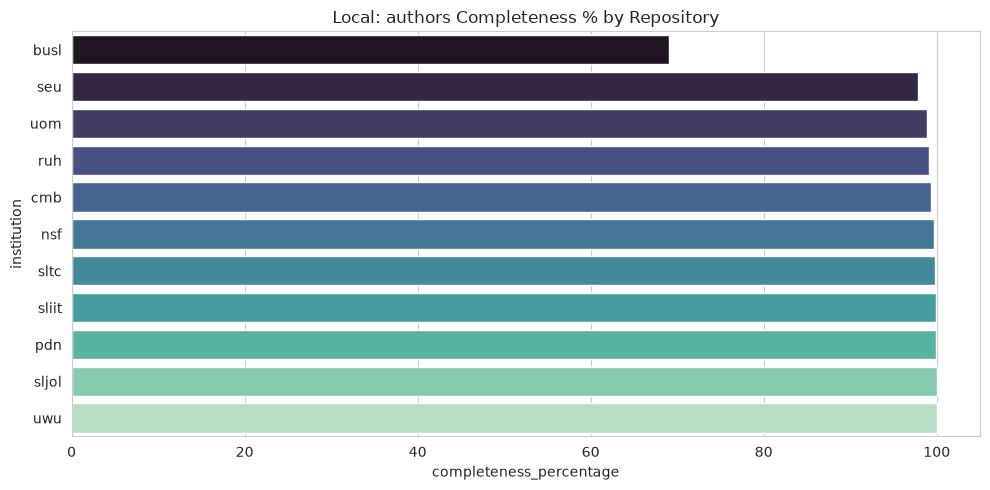

In [15]:
local_doi = inst_completeness[
    (inst_completeness["dataset"] == "Local")
    & (inst_completeness["canonical_field"] == "doi")
].sort_values("completeness_percentage")

if not local_doi.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        data=local_doi, x="completeness_percentage", y="institution", ax=ax, palette="flare"
    )
    ax.set_title("Local: DOI Completeness % by Repository")
    ax.set_xlabel("DOI completeness %")
    plt.tight_layout()
    plt.show()

for field in ["abstract", "keywords", "authors"]:
    sub = inst_completeness[
        (inst_completeness["dataset"] == "Local")
        & (inst_completeness["canonical_field"] == field)
    ].sort_values("completeness_percentage")
    if sub.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=sub, x="completeness_percentage", y="institution", ax=ax, palette="mako"
    )
    ax.set_title(f"Local: {field} Completeness % by Repository")
    plt.tight_layout()
    plt.show()


## 12. Missing-value handling playbook


In [16]:
playbook = recommendation.copy()
playbook["interpretation"] = playbook.apply(
    lambda r: (
        f"OA {r.openalex_pct}% | CR {r.crossref_pct}% | Local {r.local_pct}% -> {r.enrichment_action}"
    ),
    axis=1,
)
playbook_out = playbook[[
    "canonical_field", "preferred_primary_source", "enrichment_action",
    "openalex_pct", "crossref_pct", "local_pct", "interpretation",
]]
playbook_out.to_csv(OUTPUT_DIR / "missing_value_handling_playbook.csv", index=False)
playbook_out


,canonical_field,preferred_primary_source,enrichment_action,openalex_pct,crossref_pct,local_pct,interpretation
0,abstract,Crossref,enrich_from_crossref_when_oa_missing,0.00,44.39,70.91,OA 0.0% | CR 44.39% | Local 70.91% -> enrich_f...
1,author_affiliation,OpenAlex,keep_openalex,100.00,31.80,100.00,OA 100.0% | CR 31.8% | Local 100.0% -> keep_op...
2,author_orcid,Crossref,enrich_from_crossref_when_oa_missing,0.00,32.84,0.00,OA 0.0% | CR 32.84% | Local 0.0% -> enrich_fro...
3,authors,OpenAlex,keep_openalex,100.00,99.22,98.21,OA 100.0% | CR 99.22% | Local 98.21% -> keep_o...
4,citation_count,OpenAlex,keep_openalex,100.00,100.00,0.00,OA 100.0% | CR 100.0% | Local 0.0% -> keep_ope...
5,doi,OpenAlex,keep_openalex,97.42,100.00,41.78,OA 97.42% | CR 100.0% | Local 41.78% -> keep_o...
6,event,Crossref,enrich_from_crossref_when_oa_missing,0.00,14.40,0.00,OA 0.0% | CR 14.4% | Local 0.0% -> enrich_from...
7,funding,Crossref,enrich_from_crossref_when_oa_missing,0.00,16.28,0.00,OA 0.0% | CR 16.28% | Local 0.0% -> enrich_fro...
8,institution,OpenAlex,keep_openalex,100.00,31.80,100.00,OA 100.0% | CR 31.8% | Local 100.0% -> keep_op...
9,issn,Crossref,enrich_from_crossref_when_oa_missing,71.05,76.44,0.00,OA 71.05% | CR 76.44% | Local 0.0% -> enrich_f...


## 13. Key takeaways

1. **OpenAlex strengths:** identity, authors, Sri Lankan institutions, topics/fields, OA status,
   citations — keep these as primary.
2. **Crossref fills:** abstract, ORCID, ISSN/volume/issue/page, funding, license, event metadata,
   reference lists — enrich when OpenAlex is missing.
3. **Local fills:** keywords, some abstracts, repository provenance (`source_institution_id`);
   essential for works without DOI and grey literature / theses.
4. **Type-wise:** journal articles are richest; theses / local conference types often lack DOI
   and venue metadata — use type-aware matching and enrichment.
5. **Institute-wise:** repository DOI/abstract coverage varies widely — prioritize enrichment
   for low-DOI repos (title match -> Crossref/OpenAlex lookup).
6. Continue in **Notebook 03** for DOI-overlap enrichment opportunity counts.
